# Automatic Modulation Recognition (AMR) for DVB-S2X
**Dataset:** RadioML 2016.10A &nbsp;|&nbsp; **Model:** Random Forest &nbsp;|&nbsp; **Classes:** QPSK, 8PSK

---
Run all cells top-to-bottom from the `AMR-DVB-S2X/` working directory.

## Section 1 — Setup & Imports

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# Working directory must be AMR-DVB-S2X/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: C:\Users\anand\Desktop\ML Project\AMR-DVB-S2X


## Section 2 — Load & Explore Dataset

In [2]:
PKL_PATH    = os.path.join('data', 'RML2016.10a_dict.pkl')
TARGET_MODS = {'QPSK', '8PSK'}

print(f'Loading dataset from {PKL_PATH} ...')
with open(PKL_PATH, 'rb') as f:
    raw_data = pickle.load(f, encoding='latin1')

keys = list(raw_data.keys())
all_mods = sorted({k[0] for k in keys})
all_snrs = sorted({k[1] for k in keys})
sample_shape = raw_data[keys[0]].shape

print(f'Total entries     : {len(keys)}')
print(f'Modulation types  : {all_mods}')
print(f'SNR levels (dB)   : {all_snrs}')
print(f'Shape per entry   : {sample_shape}  -> {sample_shape[0]} samples x {sample_shape[1]} channels x {sample_shape[2]} timesteps')

Loading dataset from data\RML2016.10a_dict.pkl ...


Total entries     : 220
Modulation types  : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (dB)   : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Shape per entry   : (1000, 2, 128)  -> 1000 samples x 2 channels x 128 timesteps


In [3]:
# Filter to QPSK and 8PSK
X_list, y_list, snr_list = [], [], []
for (mod, snr), samples in raw_data.items():
    if mod not in TARGET_MODS:
        continue
    X_list.append(samples)
    y_list.extend([mod] * samples.shape[0])
    snr_list.extend([snr] * samples.shape[0])

X    = np.vstack(X_list)            # (40000, 2, 128)
y    = np.array(y_list)             # (40000,)
snrs = np.array(snr_list, dtype=int) # (40000,)

print(f'Filtered X shape : {X.shape}')
print(f'Label counts     : { {m: int((y==m).sum()) for m in sorted(set(y))} }')
print(f'SNR range        : {snrs.min()} dB to {snrs.max()} dB')

Filtered X shape : (40000, 2, 128)
Label counts     : {np.str_('8PSK'): 20000, np.str_('QPSK'): 20000}
SNR range        : -20 dB to 18 dB


## Section 3 — Data Preprocessing & EDA

### 3.1 Raw I/Q Signal Line Plot

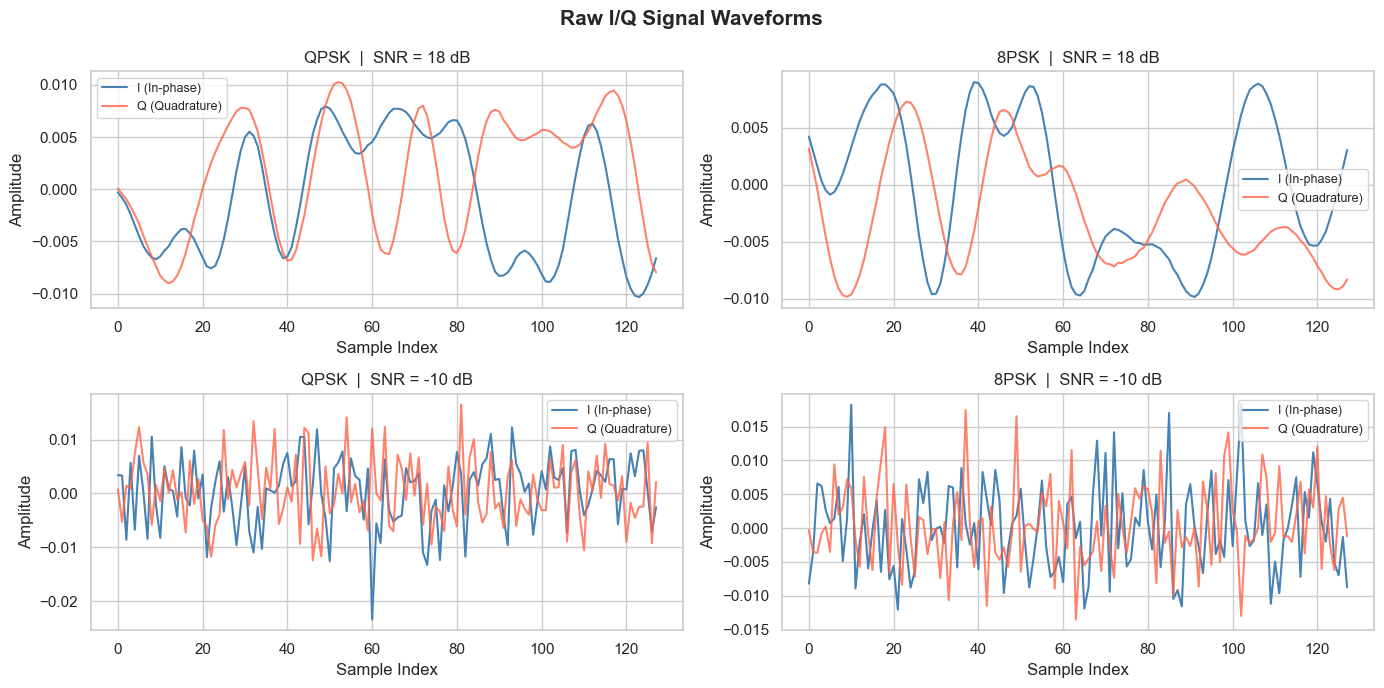

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
snr_hi, snr_lo = 18, -10
titles = [('QPSK', snr_hi), ('8PSK', snr_hi), ('QPSK', snr_lo), ('8PSK', snr_lo)]

for ax, (mod, snr) in zip(axes.flat, titles):
    mask = (y == mod) & (snrs == snr)
    sample = X[mask][0]   # first matching sample
    ax.plot(sample[0], label='I (In-phase)', color='steelblue')
    ax.plot(sample[1], label='Q (Quadrature)', color='tomato', alpha=0.8)
    ax.set_title(f'{mod}  |  SNR = {snr} dB', fontsize=12)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9)

fig.suptitle('Raw I/Q Signal Waveforms', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 IQ Constellation Scatter (I vs Q)

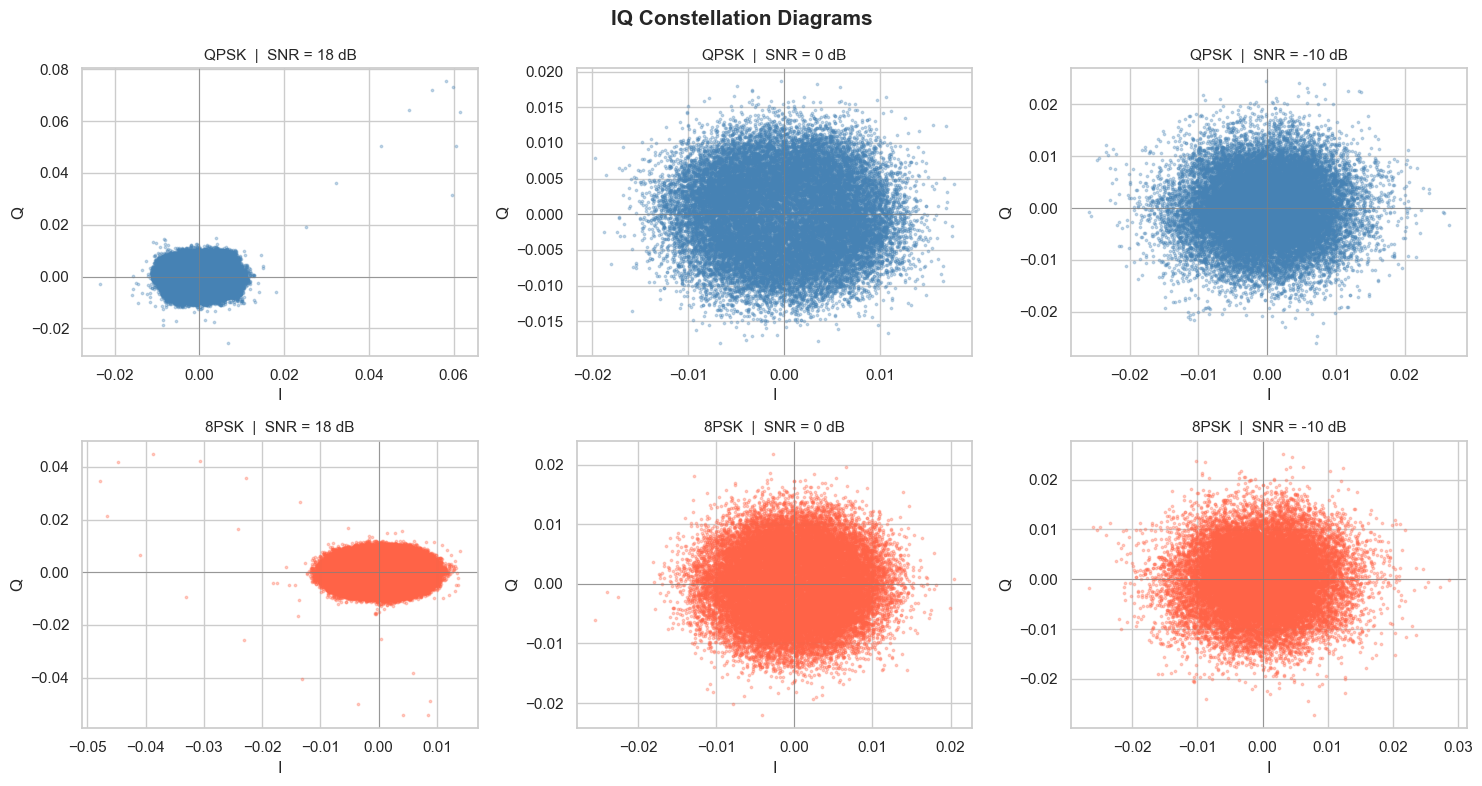

In [5]:
snr_levels = [18, 0, -10]
mods = ['QPSK', '8PSK']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, mod in enumerate(mods):
    for col, snr in enumerate(snr_levels):
        ax = axes[row, col]
        mask = (y == mod) & (snrs == snr)
        samples = X[mask][:200]  # use 200 samples for clarity
        I_vals = samples[:, 0, :].flatten()
        Q_vals = samples[:, 1, :].flatten()
        ax.scatter(I_vals, Q_vals, alpha=0.3, s=3,
                   color='steelblue' if mod == 'QPSK' else 'tomato')
        ax.set_title(f'{mod}  |  SNR = {snr} dB', fontsize=11)
        ax.set_xlabel('I')
        ax.set_ylabel('Q')
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.axvline(0, color='gray', linewidth=0.5)

fig.suptitle('IQ Constellation Diagrams', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Amplitude Distribution (Histogram)

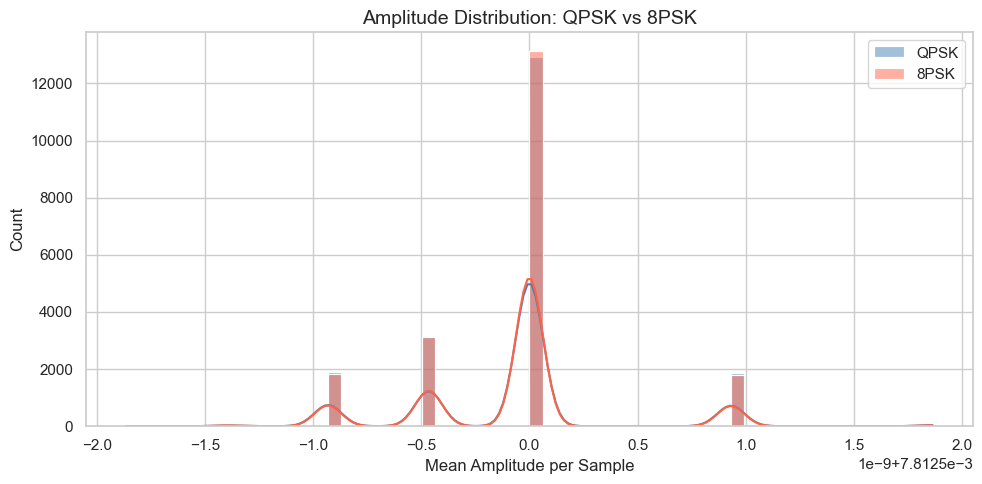

In [6]:
amp_all = np.sqrt(X[:, 0, :]**2 + X[:, 1, :]**2).mean(axis=1)  # mean amplitude per sample

fig, ax = plt.subplots(figsize=(10, 5))
for mod, color in zip(['QPSK', '8PSK'], ['steelblue', 'tomato']):
    sns.histplot(amp_all[y == mod], bins=60, kde=True, label=mod,
                 color=color, alpha=0.5, ax=ax)
ax.set_xlabel('Mean Amplitude per Sample', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Amplitude Distribution: QPSK vs 8PSK', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Phase Distribution (Histogram)

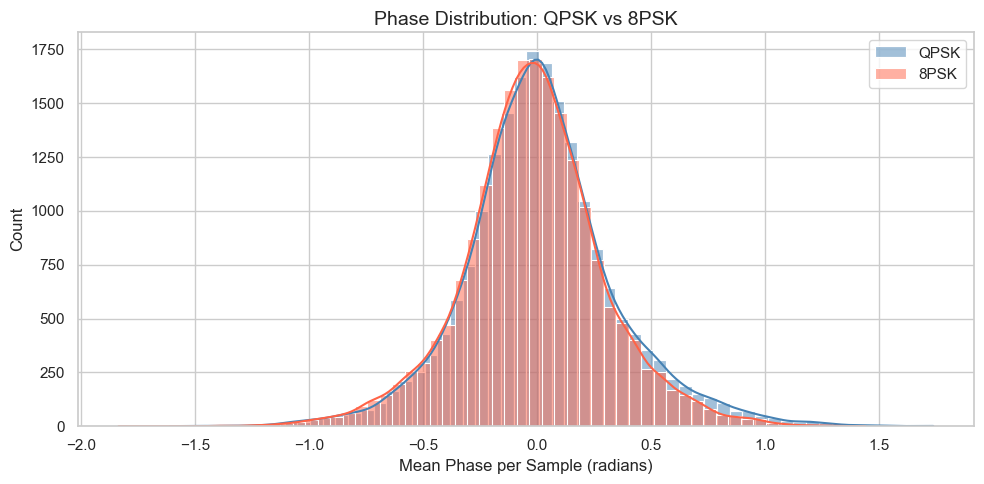

In [7]:
phase_all = np.arctan2(X[:, 1, :], X[:, 0, :]).mean(axis=1)  # mean phase per sample

fig, ax = plt.subplots(figsize=(10, 5))
for mod, color in zip(['QPSK', '8PSK'], ['steelblue', 'tomato']):
    sns.histplot(phase_all[y == mod], bins=60, kde=True, label=mod,
                 color=color, alpha=0.5, ax=ax)
ax.set_xlabel('Mean Phase per Sample (radians)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Phase Distribution: QPSK vs 8PSK', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Amplitude Box Plot per SNR Level

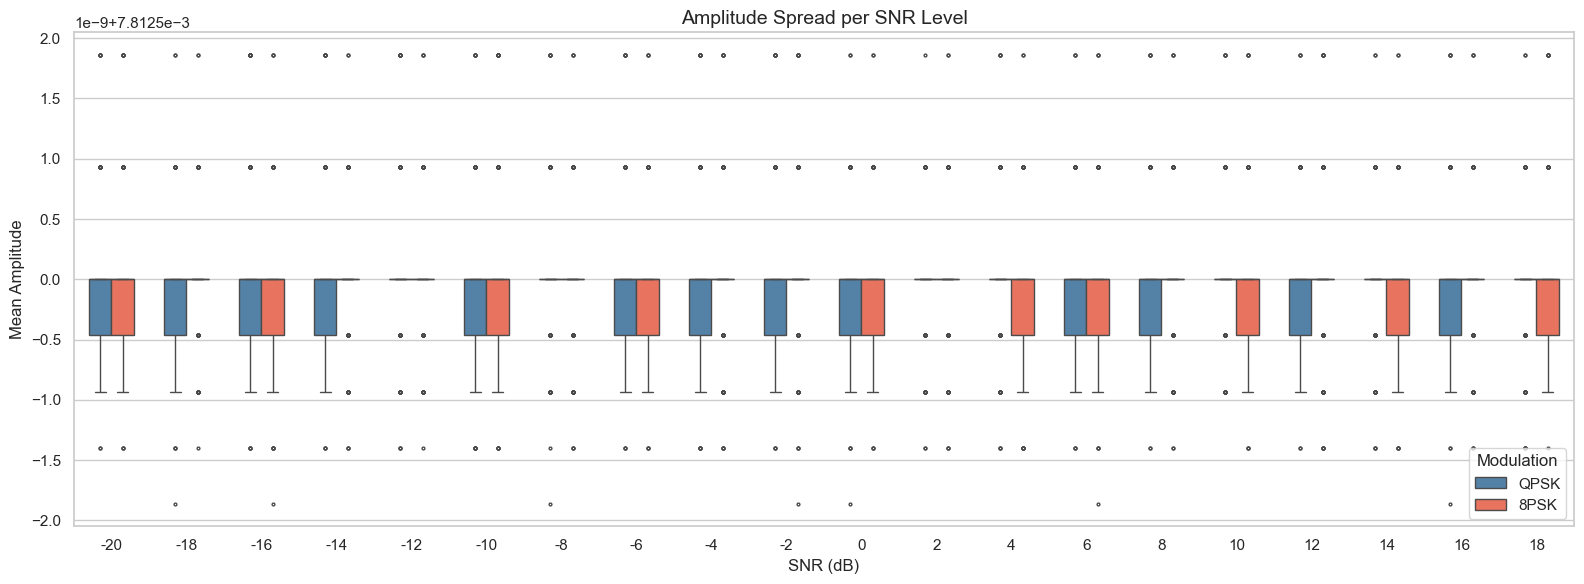

In [8]:
df_box = pd.DataFrame({
    'Mean Amplitude': amp_all,
    'SNR (dB)': snrs,
    'Modulation': y
})

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=df_box, x='SNR (dB)', y='Mean Amplitude', hue='Modulation',
            palette={'QPSK': 'steelblue', '8PSK': 'tomato'},
            width=0.6, fliersize=2, ax=ax)
ax.set_title('Amplitude Spread per SNR Level', fontsize=14)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Mean Amplitude', fontsize=12)
ax.legend(title='Modulation')
plt.tight_layout()
plt.show()

### 3.6 Sample Count Bar Chart (Dataset Balance Check)

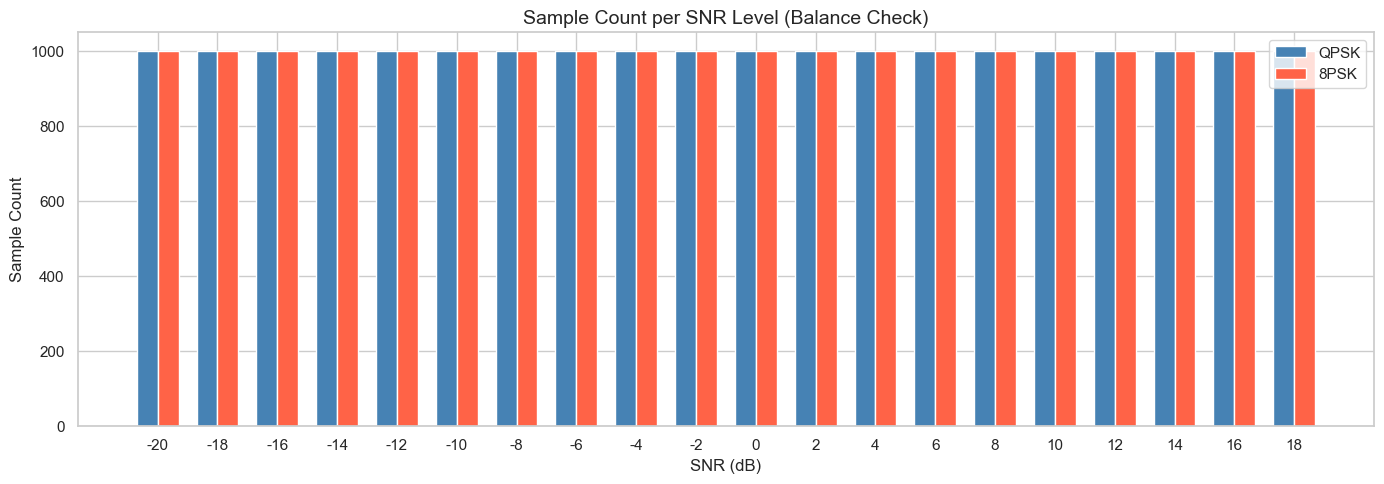

In [9]:
unique_snrs = sorted(set(snrs))
counts_qpsk = [(snrs[y == 'QPSK'] == s).sum() for s in unique_snrs]
counts_8psk = [(snrs[y == '8PSK'] == s).sum() for s in unique_snrs]

x = np.arange(len(unique_snrs))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, counts_qpsk, width, label='QPSK', color='steelblue')
ax.bar(x + width/2, counts_8psk, width, label='8PSK', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(unique_snrs)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Sample Count', fontsize=12)
ax.set_title('Sample Count per SNR Level (Balance Check)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 3.7 Mean Amplitude vs SNR (Line Plot)

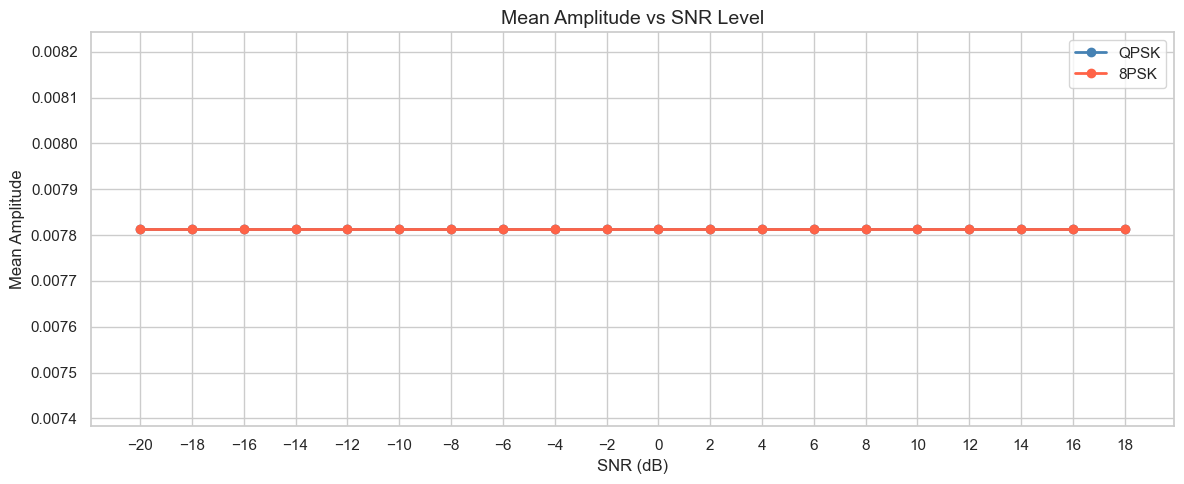

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
for mod, color in zip(['QPSK', '8PSK'], ['steelblue', 'tomato']):
    means = [amp_all[(y == mod) & (snrs == s)].mean() for s in unique_snrs]
    ax.plot(unique_snrs, means, marker='o', label=mod, color=color, linewidth=2)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Mean Amplitude', fontsize=12)
ax.set_title('Mean Amplitude vs SNR Level', fontsize=14)
ax.legend()
ax.set_xticks(unique_snrs)
plt.tight_layout()
plt.show()

### 3.8 Feature Correlation Heatmap

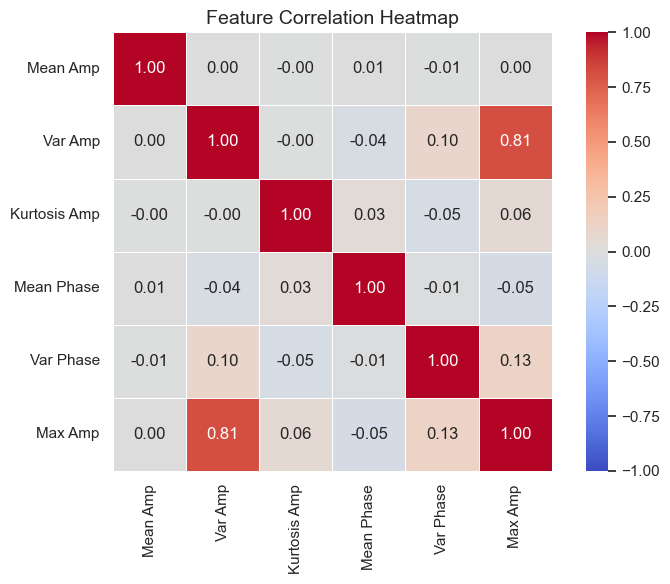


Note: Highly correlated features (|r| > 0.9) are candidates for removal.


In [11]:
# Compute features first (needed for heatmap)
I = X[:, 0, :]
Q = X[:, 1, :]
amplitude = np.sqrt(I**2 + Q**2)
phase     = np.arctan2(Q, I)

X_features = np.column_stack([
    amplitude.mean(axis=1),
    amplitude.var(axis=1),
    kurtosis(amplitude, axis=1),
    phase.mean(axis=1),
    phase.var(axis=1),
    amplitude.max(axis=1),
])
FEATURE_NAMES = ['Mean Amp', 'Var Amp', 'Kurtosis Amp', 'Mean Phase', 'Var Phase', 'Max Amp']

corr_df = pd.DataFrame(X_features, columns=FEATURE_NAMES).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()
print('\nNote: Highly correlated features (|r| > 0.9) are candidates for removal.')

## Section 4 — Feature Extraction

In [12]:
# X_features already computed in 3.8
print(f'Feature matrix shape: {X_features.shape}')
print(f'Features: {FEATURE_NAMES}\n')

df_features = pd.DataFrame(X_features, columns=FEATURE_NAMES)
df_features['Modulation'] = y
df_features['SNR'] = snrs
display(df_features.head(10))

print('\nDescriptive statistics:')
display(df_features[FEATURE_NAMES].describe().round(4))

Feature matrix shape: (40000, 6)
Features: ['Mean Amp', 'Var Amp', 'Kurtosis Amp', 'Mean Phase', 'Var Phase', 'Max Amp']



,Mean Amp,Var Amp,Kurtosis Amp,Mean Phase,Var Phase,Max Amp,Modulation,SNR
0,0.007812,0.000008,0.558705,-0.011607,3.163525,0.016470,QPSK,2
1,0.007812,0.000007,-0.042563,-0.148191,2.836757,0.014668,QPSK,2
2,0.007812,0.000008,-0.526414,0.155166,2.923380,0.014593,QPSK,2
3,0.007812,0.000009,-0.680335,-0.007726,3.040295,0.014697,QPSK,2
4,0.007813,0.000007,-0.535420,-0.070726,2.512588,0.013638,QPSK,2
5,0.007813,0.000009,-0.639523,0.516418,3.294693,0.014508,QPSK,2
6,0.007812,0.000007,-0.037016,0.619367,2.712705,0.015633,QPSK,2
7,0.007812,0.000008,-0.240188,0.714498,2.641370,0.014715,QPSK,2
8,0.007812,0.000008,-0.845584,0.609549,4.567986,0.013410,QPSK,2
9,0.007812,0.000007,0.661328,-0.271249,3.412145,0.016871,QPSK,2



Descriptive statistics:


,Mean Amp,Var Amp,Kurtosis Amp,Mean Phase,Var Phase,Max Amp
count,40000.0000,40000.0000,40000.0000,40000.0000,40000.0000,40000.0000
mean,0.0078,0.0000,0.3875,-0.0004,3.2028,0.0167
std,0.0000,0.0000,0.9281,0.3227,0.5576,0.0049
min,0.0078,0.0000,-1.8639,-1.8353,0.7966,0.0094
25%,0.0078,0.0000,-0.2302,-0.1843,2.8953,0.0119
50%,0.0078,0.0000,0.1745,-0.0079,3.2320,0.0169
75%,0.0078,0.0000,0.7798,0.1734,3.5261,0.0205
max,0.0078,0.0004,30.7280,1.7387,5.9556,0.1553


## Section 5 — Train/Test Split & Model Training

In [13]:
X_train, X_test, y_train, y_test, snrs_train, snrs_test = train_test_split(
    X_features, y, snrs,
    test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {len(y_train)}')
print(f'Test size  : {len(y_test)}')

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred   = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'\nOverall Test Accuracy: {accuracy * 100:.2f}%')

Train size : 32000
Test size  : 8000



Overall Test Accuracy: 54.79%


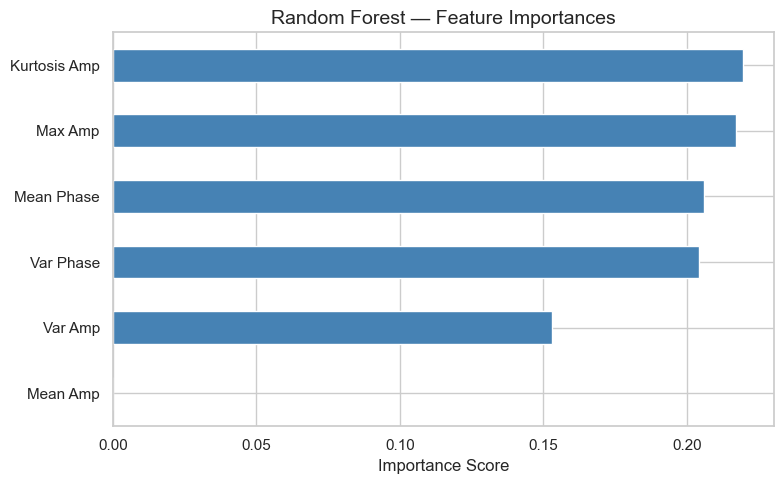

In [14]:
# Feature importance bar chart
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_NAMES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=14)
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

## Section 6 — Evaluation

In [15]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        8PSK       0.55      0.56      0.55      4000
        QPSK       0.55      0.53      0.54      4000

    accuracy                           0.55      8000
   macro avg       0.55      0.55      0.55      8000
weighted avg       0.55      0.55      0.55      8000



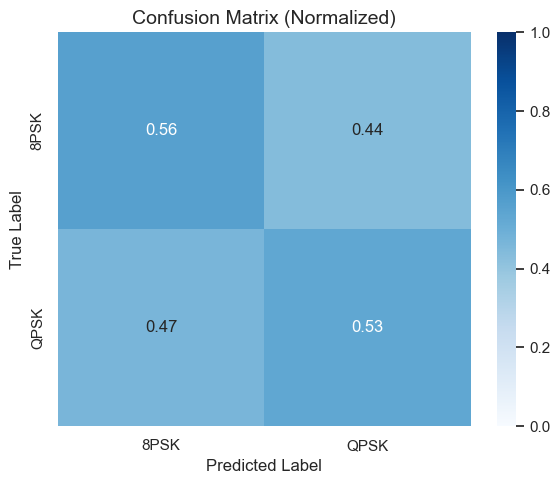

In [16]:
# Confusion Matrix
classes = sorted(set(y_test))
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Normalized)', fontsize=14)
plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/confusion_matrix_nb.png', dpi=150)
plt.show()

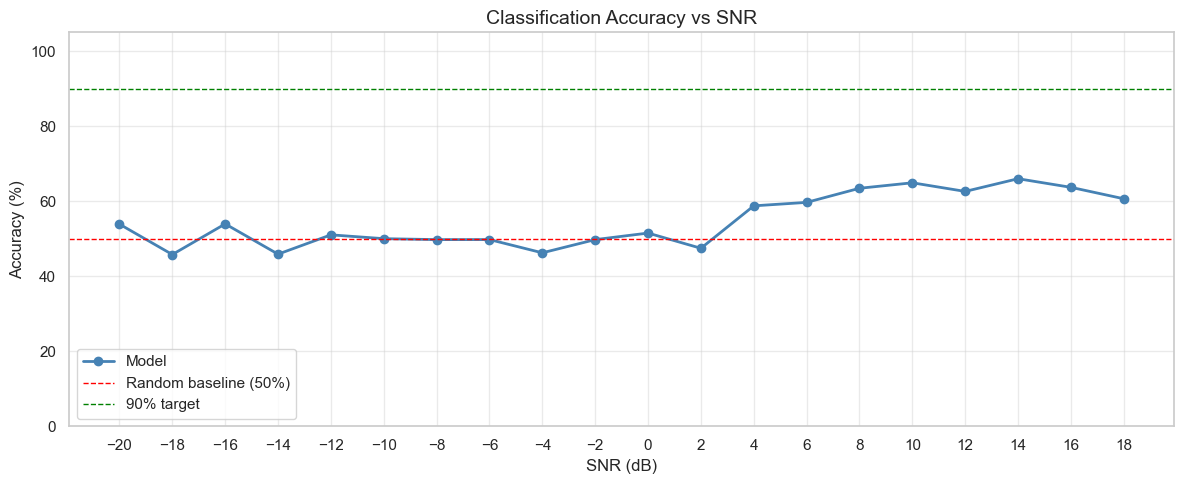


Accuracy per SNR:
  SNR  -20 dB : 53.87%
  SNR  -18 dB : 45.77%
  SNR  -16 dB : 53.93%
  SNR  -14 dB : 45.87%
  SNR  -12 dB : 51.02%
  SNR  -10 dB : 50.00%
  SNR   -8 dB : 49.75%
  SNR   -6 dB : 49.76%
  SNR   -4 dB : 46.23%
  SNR   -2 dB : 49.75%
  SNR    0 dB : 51.49%
  SNR    2 dB : 47.44%
  SNR    4 dB : 58.75%
  SNR    6 dB : 59.67%
  SNR    8 dB : 63.43%
  SNR   10 dB : 64.90%
  SNR   12 dB : 62.60%
  SNR   14 dB : 65.98%
  SNR   16 dB : 63.68%
  SNR   18 dB : 60.64%


In [17]:
# Accuracy vs SNR
unique_snrs_test = sorted(set(snrs_test))
acc_per_snr = [
    accuracy_score(y_test[snrs_test == s], y_pred[snrs_test == s]) * 100
    for s in unique_snrs_test
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(unique_snrs_test, acc_per_snr, marker='o', linewidth=2, color='steelblue', label='Model')
ax.axhline(50, color='red',   linestyle='--', linewidth=1, label='Random baseline (50%)')
ax.axhline(90, color='green', linestyle='--', linewidth=1, label='90% target')
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Classification Accuracy vs SNR', fontsize=14)
ax.set_ylim(0, 105)
ax.set_xticks(unique_snrs_test)
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('results/accuracy_per_snr_nb.png', dpi=150)
plt.show()

print('\nAccuracy per SNR:')
for s, a in zip(unique_snrs_test, acc_per_snr):
    print(f'  SNR {s:>4} dB : {a:.2f}%')